In [1]:
import pandas
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.impute import SimpleImputer
from matplotlib.colors import LogNorm
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_curve, auc, precision_score, recall_score, f1_score, precision_recall_fscore_support, ConfusionMatrixDisplay

In [2]:
BLACK = '\033[30m'
RED = '\033[31m'
GREEN = '\033[32m'
YELLOW = '\033[33m' # orange on some systems
BLUE = '\033[34m'
MAGENTA = '\033[35m'
CYAN = '\033[36m'
LIGHT_GRAY = '\033[37m'
DARK_GRAY = '\033[90m'
BRIGHT_RED = '\033[91m'
BRIGHT_GREEN = '\033[92m'
BRIGHT_YELLOW = '\033[93m'
BRIGHT_BLUE = '\033[94m'
BRIGHT_MAGENTA = '\033[95m'
BRIGHT_CYAN = '\033[96m'
RESET = '\033[0m' # called to return to standard terminal text color

def colored_text(color, txt):
    return color + str(txt) + RESET

In [3]:
datasets_path = "data"
years = [2019,2020, 2021, 2022, 2023, 2024]

df_usagers = []

for year in years:
    df_usagers_year = pandas.read_csv(os.path.join(datasets_path, str(year), f"usagers-{year}.csv"), encoding="utf-8", sep = ";")
    df_usagers.append(df_usagers_year)

df_usagers = pandas.concat(df_usagers)
df_usagers

,Num_Acc,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp,id_usager
0,201900000001,138 306 524,B01,2,2,4,2,2002.0,0,1,0,-1,-1,-1,-1,NaN
1,201900000001,138 306 524,B01,1,1,4,2,1993.0,5,1,0,-1,-1,-1,-1,NaN
2,201900000001,138 306 525,A01,1,1,1,1,1959.0,0,1,0,-1,-1,-1,-1,NaN
3,201900000002,138 306 523,A01,1,1,4,2,1994.0,0,1,0,-1,-1,-1,-1,NaN
4,201900000003,138 306 520,A01,1,1,1,1,1996.0,0,1,0,-1,-1,0,-1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125182,202400054401,155 686 119,Y01,1,1,4,2,1978.0,0,0,0,0,-1,-1,-1,203 859 570
125183,202400054401,155 686 120,A01,1,1,1,1,1984.0,0,2,6,0,-1,-1,-1,203 859 572
125184,202400054402,155 686 118,A01,1,1,4,1,1981.0,4,1,0,-1,-1,-1,-1,203 859 569
125185,202400054402,155 686 121,B01,1,1,4,2,1986.0,9,1,0,-1,-1,-1,-1,203 859 571


In [4]:
df_usagers.info()

<class 'pandas.DataFrame'>
Index: 745158 entries, 0 to 125186
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Num_Acc      745158 non-null  int64  
 1   id_vehicule  745158 non-null  str    
 2   num_veh      745158 non-null  str    
 3   place        745158 non-null  int64  
 4   catu         745158 non-null  int64  
 5   grav         745158 non-null  int64  
 6   sexe         745158 non-null  int64  
 7   an_nais      734040 non-null  float64
 8   trajet       745158 non-null  int64  
 9   secu1        745158 non-null  int64  
 10  secu2        745158 non-null  int64  
 11  secu3        745158 non-null  int64  
 12  locp         745158 non-null  int64  
 13  actp         745158 non-null  str    
 14  etatp        745158 non-null  int64  
 15  id_usager    506886 non-null  str    
dtypes: float64(1), int64(11), str(4)
memory usage: 96.6 MB


In [5]:
df_usagers.drop(columns=["num_veh", "id_usager"] ,inplace=True)

In [6]:
df_usagers["id_vehicule"] = (
    df_usagers["id_vehicule"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)  # keep only digits
    .astype("int64")
)

In [7]:
column_names_to_int = ["place", "catu", "grav", "sexe", "an_nais", "trajet", "secu1", "secu2", "secu3", "locp", "actp", "etatp"]

df_usagers[column_names_to_int] = df_usagers[column_names_to_int].apply(
    lambda col: pandas.to_numeric(
        col.astype(str).str.extract(r'(-?\d+)')[0],
        errors="coerce"
    ),
    axis=0 # for each column
)
df_usagers.info()

<class 'pandas.DataFrame'>
Index: 745158 entries, 0 to 125186
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Num_Acc      745158 non-null  int64  
 1   id_vehicule  745158 non-null  int64  
 2   place        745158 non-null  int64  
 3   catu         745158 non-null  int64  
 4   grav         745158 non-null  int64  
 5   sexe         745158 non-null  int64  
 6   an_nais      734040 non-null  float64
 7   trajet       745158 non-null  int64  
 8   secu1        745158 non-null  int64  
 9   secu2        745158 non-null  int64  
 10  secu3        745158 non-null  int64  
 11  locp         745158 non-null  int64  
 12  actp         742496 non-null  float64
 13  etatp        745158 non-null  int64  
dtypes: float64(2), int64(12)
memory usage: 85.3 MB


In [8]:
df_usagers.replace(-1, pandas.NA, inplace=True)
df_usagers["trajet"] = df_usagers["trajet"].replace(0, pandas.NA) # For trajet -1 and 0 mean missing value

for col in df_usagers.columns:
    prop = df_usagers[col].isna().sum() / df_usagers.shape[0]
    print(f"For {colored_text(MAGENTA, col)} proportion missing: {prop * 100:.2f}%")

For Num_Acc proportion missing: 0.00%
For id_vehicule proportion missing: 0.00%
For place proportion missing: 0.00%
For catu proportion missing: 0.00%
For grav proportion missing: 0.06%
For sexe proportion missing: 1.43%
For an_nais proportion missing: 1.49%
For trajet proportion missing: 27.76%
For secu1 proportion missing: 1.34%
For secu2 proportion missing: 40.63%
For secu3 proportion missing: 97.31%
For locp proportion missing: 45.88%
For actp proportion missing: 42.05%
For etatp proportion missing: 92.18%


In [9]:
df_usagers["trajet"] = df_usagers["trajet"].replace(pandas.NA, 0) 

In [10]:
df_usagers = df_usagers.dropna(subset=["grav","sexe","an_nais", "place", "catu"])

As for secu1, secu2 and secu3 these are important but we have ot convert these into more meaningfull and usable form.

For this, let's see their distribution and how they relate to gravity

In [11]:
equipments = {
    0: "aucun",
    1: "ceinture",
    2: "casque",
    3: "dispositif_enfant",
    4: "gilet_reflechissant",
    5: "airbag",
    6: "gants",
    8: "non determinable",
    9: "autre"
}
def encode_secu(df):
    df = df.copy()
    for name in equipments.values():
        df[name] = 0 # for every row, no equipment used by default

    for col in ["secu1", "secu2", "secu3"]:
        for code, name in equipments.items():
            df.loc[df[col] == code, name] = 1

    # if any equipment used → aucun = 0 else aucun = 1
    protection_cols = [c for c in equipments.values() if c != "aucun"]

    df.loc[df[protection_cols].sum(axis=1) > 0, "aucun"] = 0
    df.loc[df[protection_cols].sum(axis=1) == 0, "aucun"] = 1
    
    return df

df_usagers = encode_secu(df_usagers)    
df_usagers.drop(columns=["secu1", "secu2", "secu3"],inplace=True)

In [12]:
df_no_protection = df_usagers[
    (df_usagers["aucun"] == 1) &
    (df_usagers["catu"] != 3)
] # hors piétons

/var/folders/px/f5rzp1jd67g9q5g45r_l7v840000gn/T/ipykernel_61537/1134883370.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


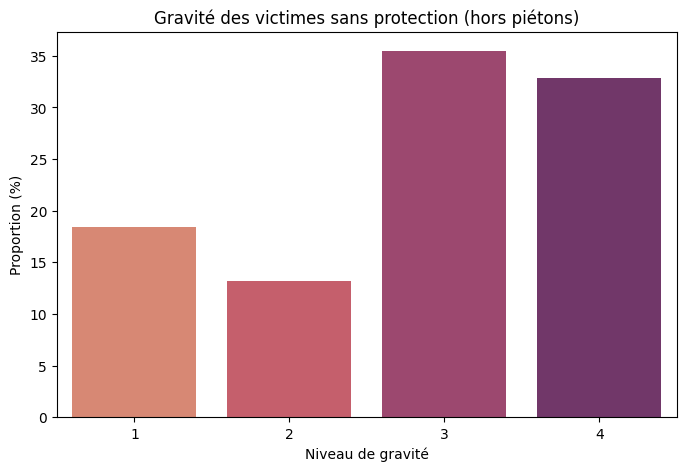

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_no_protection,
    x="grav",
    stat="percent",
    palette="flare"
)

plt.title("Gravité des victimes sans protection (hors piétons)")
plt.xlabel("Niveau de gravité")
plt.ylabel("Proportion (%)")
plt.show()

In [14]:
df_usagers["age"] = 2026 - df_usagers["an_nais"]
df_usagers.drop(columns="an_nais", inplace=True)

In [15]:
df_usagers["age"].describe()

count    734019.000000
mean         43.083614
std          19.089808
min           2.000000
25%          28.000000
50%          40.000000
75%          56.000000
max         126.000000
Name: age, dtype: float64

In [16]:
len(df_usagers[df_usagers["age"] > 100])

473

In [17]:
df_usagers[df_usagers["age"] > 100]["age"].value_counts().sort_index()

age
101.0    117
102.0     55
103.0     44
104.0     25
105.0     12
106.0     10
107.0      5
109.0      1
111.0      2
112.0      1
113.0      5
114.0      1
115.0      1
116.0      3
125.0     43
126.0    148
Name: count, dtype: int64

In [18]:
df_usagers = df_usagers[df_usagers["age"] <= 100]

<Axes: xlabel='age', ylabel='Count'>

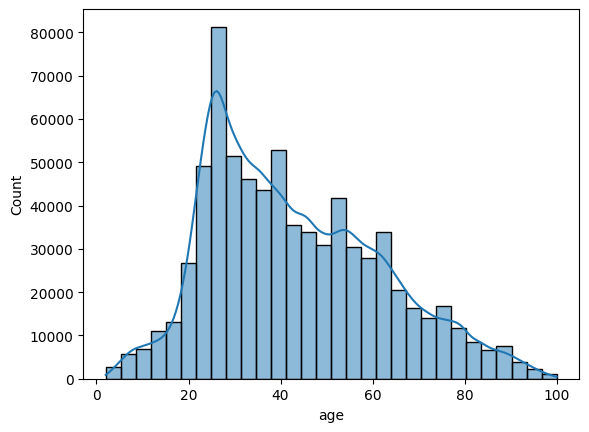

In [19]:
sns.histplot(df_usagers["age"], bins=30, kde=True) 

In [20]:
# On va aussi ajouter une colonne accident grave ou non pour faire une classification binaire, ca sera notre target
df_usagers["grav_bin"] = df_usagers["grav"].replace({
    1: 0,  # Non grave
    4: 0,  # Non grave
    2: 1,  # Grave
    3: 1   # Grave
})

In [21]:
mapping = {
    0: "Not severly injured",
    1: "Severly injured"
}

counts = df_usagers["grav_bin"].value_counts()
counts.index = counts.index.map(mapping)

for cl, prop in counts.items():
    print(f"For {colored_text(MAGENTA, cl)} proportion: {prop / len(df_usagers) * 100:.2f}%")

For Not severly injured proportion: 81.71%
For Severly injured proportion: 18.29%


In [22]:
mapping = {
    1: "Unharmed",
    2: "Killed",
    3: "Hospitalized injury",
    4: "Minor injury"
}

counts = df_usagers["grav"].value_counts()
counts.index = counts.index.map(mapping)

for cl, prop in counts.items():
    print(f"For {colored_text(MAGENTA, cl)} proportion: {prop / len(df_usagers) * 100:.2f}%")

For Unharmed proportion: 41.28%
For Minor injury proportion: 40.44%
For Hospitalized injury proportion: 15.58%
For Killed proportion: 2.70%


In [23]:
cols_int = ["place", "catu", "sexe", "age", "aucun", "ceinture", "casque","trajet", "dispositif_enfant", "gilet_reflechissant", "airbag", "gants", "autre", "grav_bin", "grav"]
df_usagers[cols_int] = df_usagers[cols_int].astype("int64")

In [24]:
df_usagers.columns

Index(['Num_Acc', 'id_vehicule', 'place', 'catu', 'grav', 'sexe', 'trajet',
       'locp', 'actp', 'etatp', 'aucun', 'ceinture', 'casque',
       'dispositif_enfant', 'gilet_reflechissant', 'airbag', 'gants',
       'non determinable', 'autre', 'age', 'grav_bin'],
      dtype='str')

In [25]:
features = ['place', 'catu', 'sexe', 'age', 
       'aucun', 'ceinture', 'casque', 'dispositif_enfant', "trajet",
       'gilet_reflechissant', 'airbag', 'gants',"non determinable", 'autre']


binary_features = ['aucun', 'ceinture', 'casque', 'dispositif_enfant', 'gilet_reflechissant', 'airbag', 'gants', "non determinable", 'autre']
numerical_features = ["age"]
categorical_features = list(set(features) - set(binary_features) - set(numerical_features))

target = 'grav_bin'

In [26]:
df_usagers_analyse = df_usagers.copy()
mapping = {
    1: "Conducteur",
    2: "Passager avant droit",
    3: "Passager arrière droit",
    4: "Passager arrière gauche",
    5: "Passager avant gauche",
    6: "Autre place véhicule léger",
    7: "Transport en commun - place assise",
    8: "Transport en commun - debout",
    9: "Autre transport en commun",
    10: "Piéton (non applicable)"
}

df_usagers_analyse["place"] = df_usagers_analyse["place"].replace(mapping)

mapping = {
    1: "Conducteur",
    2: "Passager",
    3: "Piéton"
}
df_usagers_analyse["catu"] = df_usagers_analyse["catu"].replace(mapping)

mapping = {
    1: "Masculin",
    2: "Féminin"
}
df_usagers_analyse["sexe"] = df_usagers_analyse["sexe"].replace(mapping)

mapping = {
    0: "Non renseigné",
    1: "Domicile – travail",
    2: "Domicile – école",
    3: "Courses – achats",
    4: "Utilisation professionnelle",
    5: "Promenade – loisirs",
    9: "Autre"
}
df_usagers_analyse["trajet"] = df_usagers_analyse["trajet"].replace(mapping)

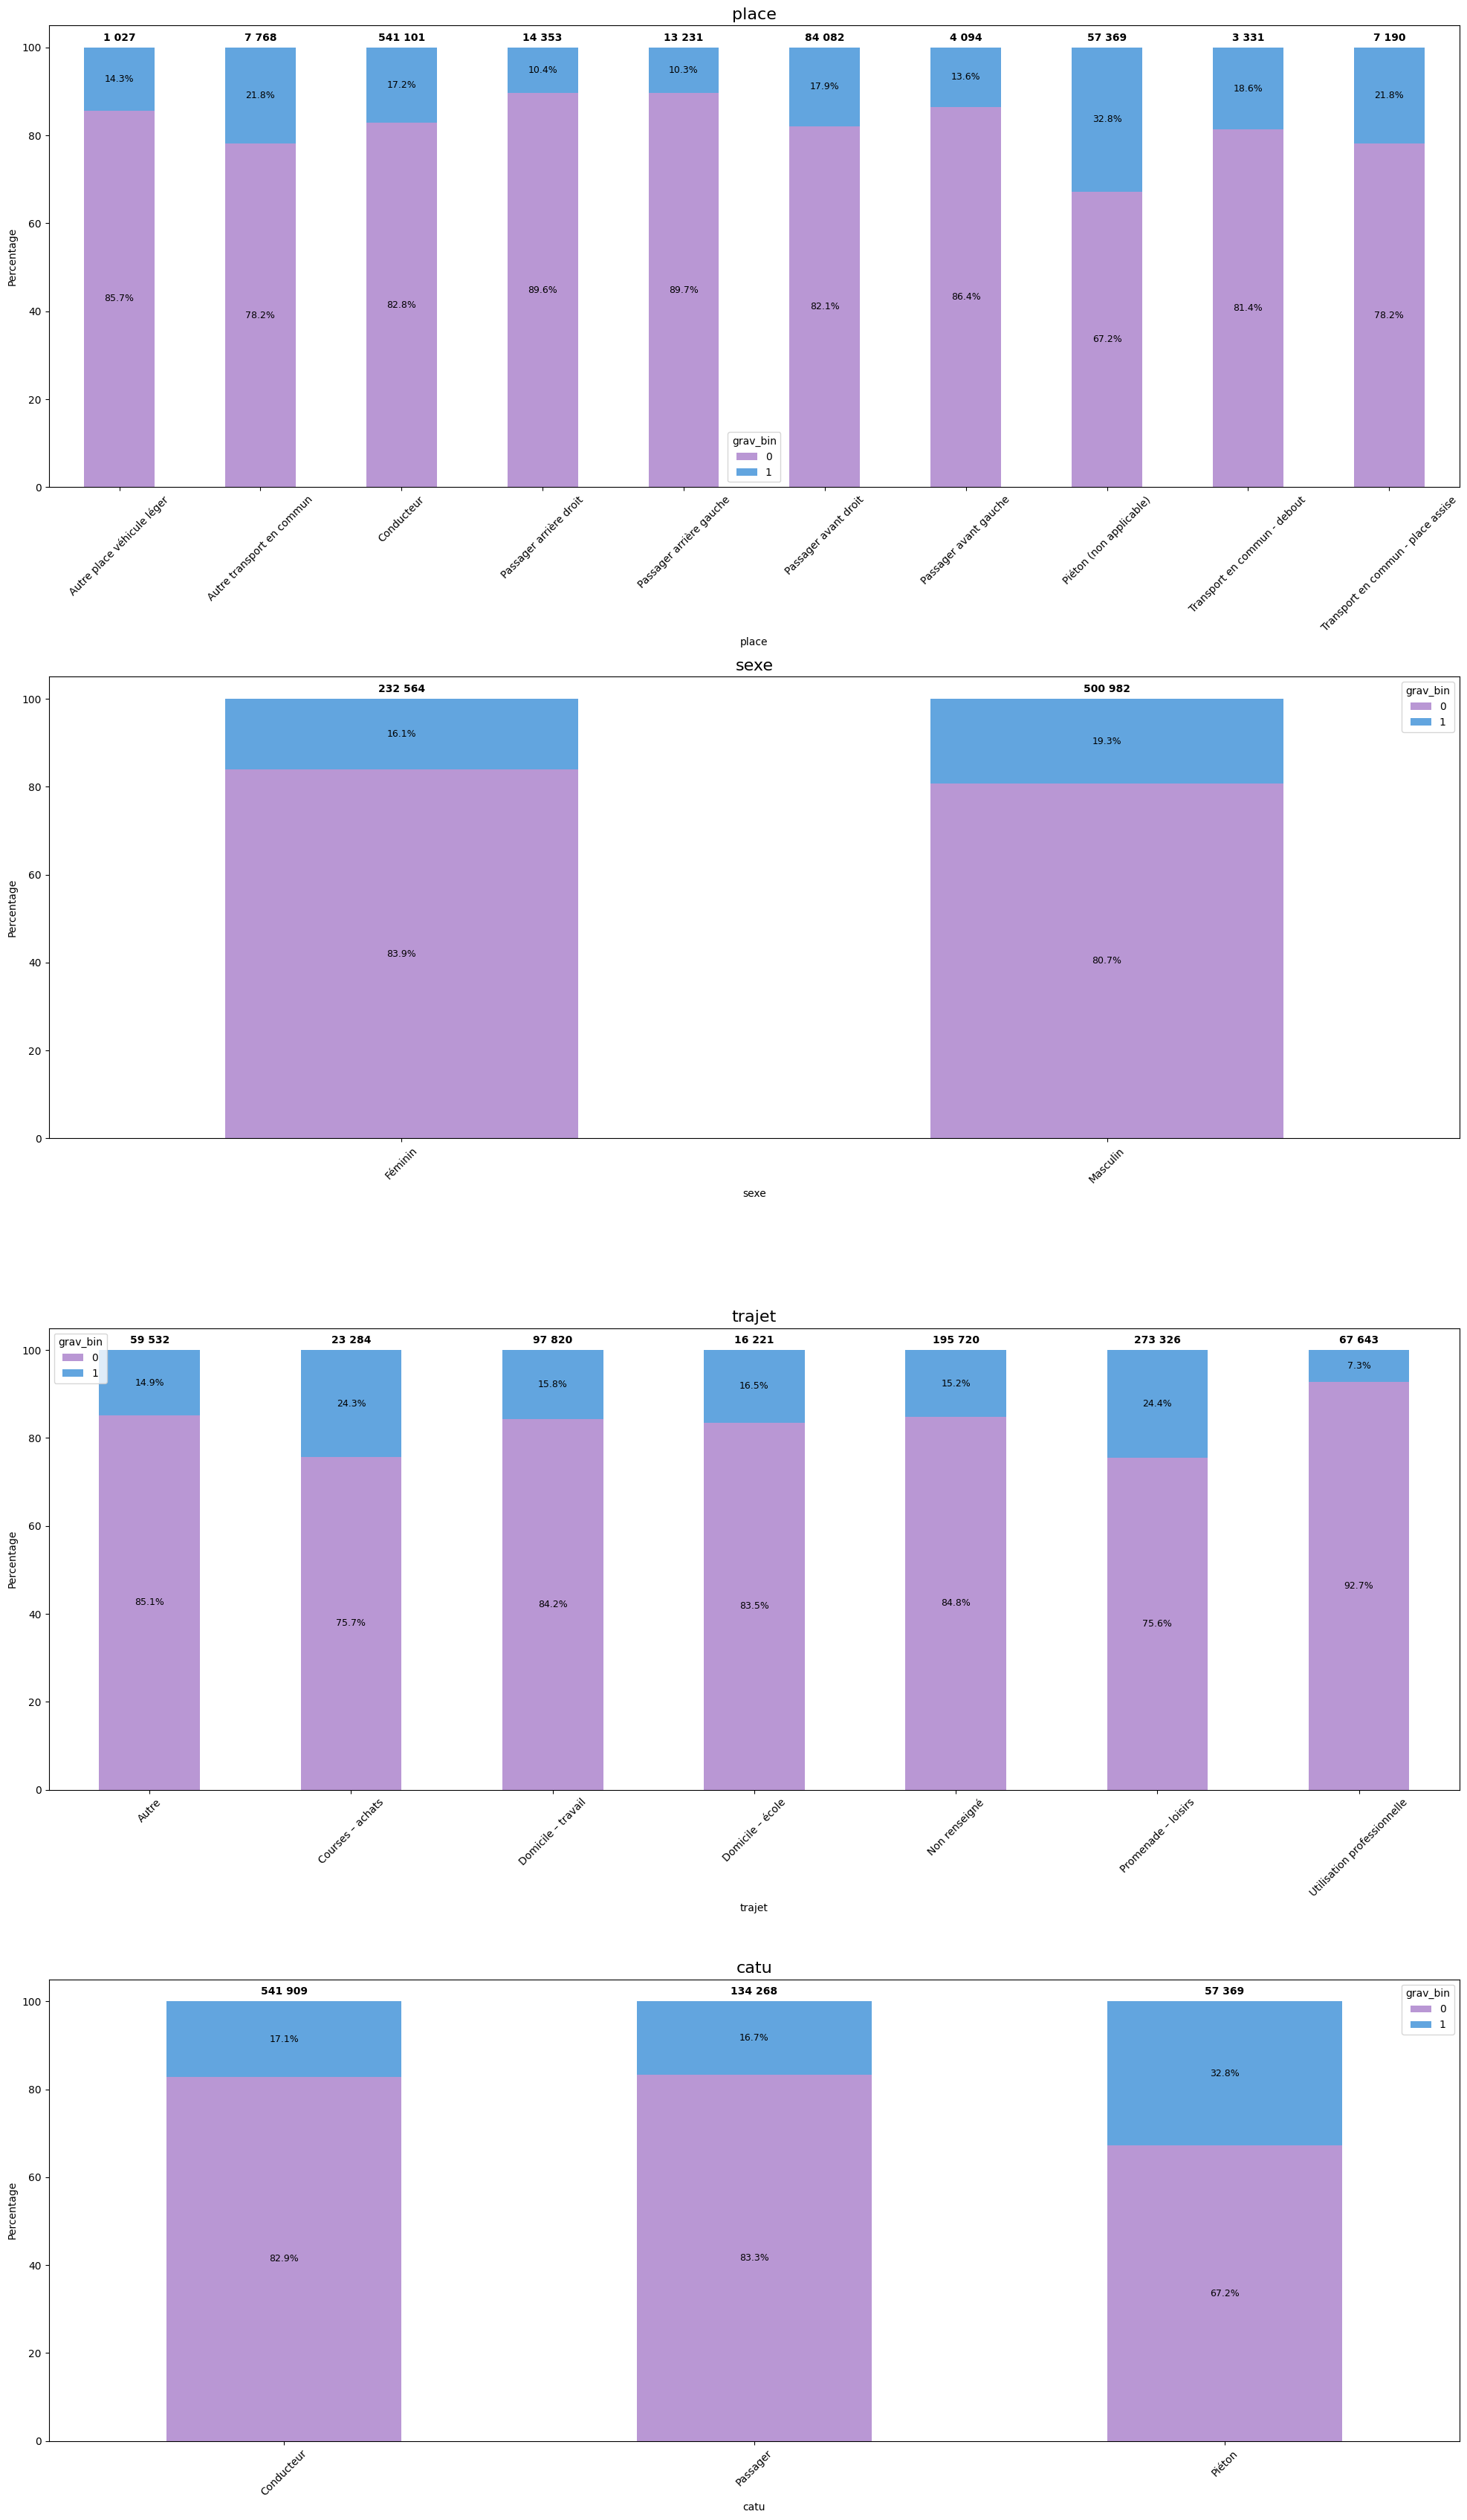

In [27]:
fig, ax = plt.subplots(len(categorical_features), 1, figsize=(20, 6*len(categorical_features) + 10))

df_usagers_analyse = df_usagers_analyse.reset_index(drop=True)

for i, feature in enumerate(categorical_features):
    ct = pandas.crosstab(
        df_usagers_analyse[feature],
        df_usagers_analyse[target],
        normalize="index"
    ) * 100

    counts = df_usagers_analyse[feature].value_counts().sort_index()

    # Plot
    ct.plot(kind="bar", stacked=True, ax=ax[i], color=["#B997D4", "#62A5DF"])

    # Add % labels inside bars
    for j, category in enumerate(ct.index):
        cumulative = 0
        for k, col in enumerate(ct.columns):
            value = ct.loc[category, col]
            if value > 3:  # avoid clutter for tiny values
                ax[i].text(
                    j,
                    cumulative + value / 2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black"
                )
            cumulative += value

    # Add total count above bars
    for j, category in enumerate(ct.index):
        ax[i].text(
            j,
            101,  # slightly above 100%
            f"{counts[category]:,}".replace(",", " "),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax[i].set_title(feature, fontsize=16)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylabel("Percentage")

plt.tight_layout()

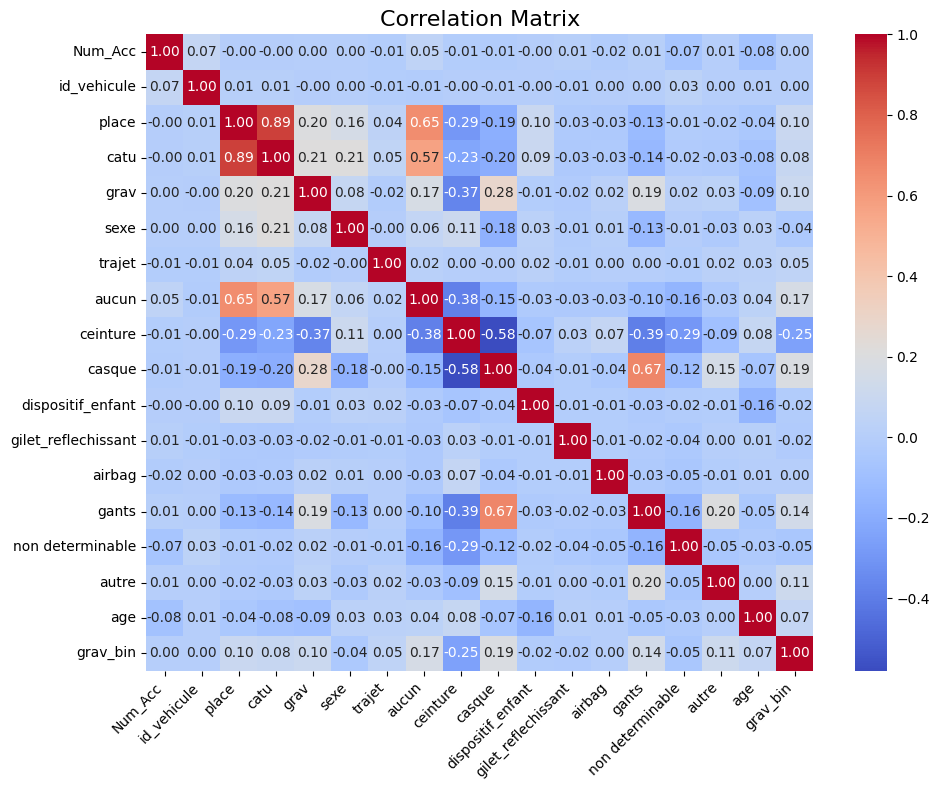

In [28]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df_usagers[['Num_Acc', 'id_vehicule', 'place', 'catu', 'grav', 'sexe', 'trajet', 'aucun', 'ceinture', 'casque',
       'dispositif_enfant', 'gilet_reflechissant', 'airbag', 'gants', 
       'non determinable', 'autre', 'age', 'grav_bin']].corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10}
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [29]:
binary_features = [
    'aucun', 'ceinture', 'casque', 'dispositif_enfant',
    'gilet_reflechissant', 'airbag', 'gants',
    'non determinable', 'autre'
]
numerical_features = ["age"]
categorical_features = list(
    set(features) - set(binary_features) - set(numerical_features))

In [30]:
X = df_usagers[features]
y = df_usagers[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=df_usagers[target]
)

In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features),
        ("bin", "passthrough", binary_features)
    ]
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

pipelines = {}
for name, model in models.items():
    pipelines[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

for name, pipe in pipelines.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=5) # un label prédit pour chaque exemple de X_train
    
    precision = precision_score(y_train,y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train,y_pred)
    accuracy = accuracy_score(y_train, y_pred)

    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_train, y_pred))


 Logistic Regression
Precision: 0.5974797293807778
Recall: 0.10781618407686644
F1: 0.18266938247043404
Accuracy: 0.823582738618626
              precision    recall  f1-score   support

           0       0.83      0.98      0.90    479533
           1       0.60      0.11      0.18    107303

    accuracy                           0.82    586836
   macro avg       0.71      0.55      0.54    586836
weighted avg       0.79      0.82      0.77    586836


 Decision Tree
Precision: 0.5250093086756857
Recall: 0.15768431451124387
F1: 0.24252675032788412
Accuracy: 0.819896870675964
              precision    recall  f1-score   support

           0       0.84      0.97      0.90    479533
           1       0.53      0.16      0.24    107303

    accuracy                           0.82    586836
   macro avg       0.68      0.56      0.57    586836
weighted avg       0.78      0.82      0.78    586836


 Gradient Boosting
Precision: 0.6017665293643042
Recall: 0.1320652731051322
F1: 0.21659

In [32]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size = .2)
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val) # un label prédit pour chaque exemple de X_train
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, y_pred, average="binary")
    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_val, y_pred))


 Logistic Regression
Precision: 0.5949948927477018
Recall: 0.10848309898500791
F1: 0.1835079152555722
Accuracy: 0.8253174651861849
              precision    recall  f1-score   support

           0       0.83      0.98      0.90     95890
           1       0.59      0.11      0.18     21478

    accuracy                           0.82    117368
   macro avg       0.71      0.55      0.54    117368
weighted avg       0.79      0.82      0.77    117368


 Decision Tree
Precision: 0.661949179800579
Recall: 0.19163795511686377
F1: 0.2972270363951473
Accuracy: 0.8253174651861849
              precision    recall  f1-score   support

           0       0.84      0.98      0.91     95890
           1       0.66      0.19      0.30     21478

    accuracy                           0.83    117368
   macro avg       0.75      0.58      0.60    117368
weighted avg       0.81      0.83      0.79    117368


 Gradient Boosting
Precision: 0.6005824838776784
Recall: 0.1344166123475184
F1: 0.219669

AUC of Logistic Regression: 0.735
AUC of Decision Tree: 0.718
AUC of Gradient Boosting: 0.745


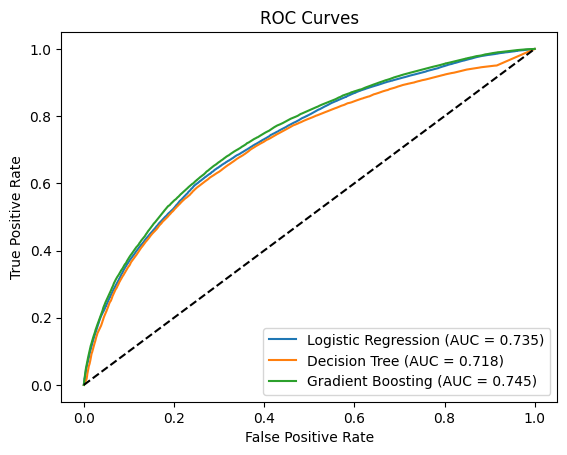

In [33]:
plt.figure()

lst_auc = []

for name, pipeline in pipelines.items():

    y_proba = pipeline.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)

    lst_auc.append((name, auc_score))

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

    print(f"AUC of {name}: {auc_score:.3f}")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

Now we will study more the pedestrian category (piéton) :

The attributes place and catu ( catégorie de l'usager ) are always known. When catu = 3 (piéton) place must be equal 10 (non applicable pour le piéton) and vice versa .

we notice that we have one incorrect example we don't take it into consideration 

In [34]:
# 2. Détection des incohérences
incoherences = df_usagers[
    ((df_usagers["place"] == 10) & (df_usagers["catu"] != 3)) |
    ((df_usagers["catu"] == 3) & (df_usagers["place"] != 10))
]

print("Number of inconsistent examples : ",  incoherences.shape[0])

df_usagers.drop(incoherences.index, inplace=True) 



Number of inconsistent examples :  0


In [35]:
df_pedestrians = df_usagers[df_usagers["catu"] == 3]

In [36]:
features_pedestrians = [ 'sexe', 'trajet',
       'locp', 'actp', 'etatp', 'age',"aucun", "gilet_reflechissant", "non determinable", 'autre']
target = "grav_bin"
df_pedestrians_n = df_pedestrians.dropna(subset=features_pedestrians)

In [37]:
df_pedestrians_n[binary_features].sum()

aucun                  43193
ceinture                   0
casque                     0
dispositif_enfant          0
gilet_reflechissant      251
airbag                     0
gants                      0
non determinable       10588
autre                    155
dtype: int64

In [38]:
numerical_features = ["age"]
binary_features = ["aucun", "gilet_reflechissant", "non determinable", 'autre']
categorical_features = list(
    set(features_pedestrians) - set(numerical_features) - set(binary_features))


In [39]:
X = df_pedestrians_n[features_pedestrians]
y = df_pedestrians_n[target]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=df_pedestrians_n[target]
)

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

pipelines = {
    name: Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

for name, pipe in pipelines.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=5) # un label prédit pour chaque exemple de X_train
    
    precision = precision_score(y_train,y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train,y_pred)
    accuracy = accuracy_score(y_train, y_pred)

    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_train, y_pred))


 Logistic Regression
Precision: 0.5752596789423985
Recall: 0.21627378585629084
F1: 0.3143609061355075
Accuracy: 0.6932258958256372
              precision    recall  f1-score   support

           0       0.71      0.92      0.80     29228
           1       0.58      0.22      0.31     14084

    accuracy                           0.69     43312
   macro avg       0.64      0.57      0.56     43312
weighted avg       0.67      0.69      0.64     43312


 Decision Tree
Precision: 0.447597582214937
Recall: 0.31021016756603237
F1: 0.36644998951562174
Accuracy: 0.6512052087181381
              precision    recall  f1-score   support

           0       0.71      0.82      0.76     29228
           1       0.45      0.31      0.37     14084

    accuracy                           0.65     43312
   macro avg       0.58      0.56      0.56     43312
weighted avg       0.62      0.65      0.63     43312


 Gradient Boosting
Precision: 0.5782926450007775
Recall: 0.26405850610621984
F1: 0.3625

In [41]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size = .2)
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val) # un label prédit pour chaque exemple de X_train
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, y_pred, average="binary")
    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_val, y_pred))


 Logistic Regression
Precision: 0.5647517039922103
Recall: 0.20480225988700565
F1: 0.3005960093288417
Accuracy: 0.6980744366457333
              precision    recall  f1-score   support

           0       0.71      0.92      0.80      5831
           1       0.56      0.20      0.30      2832

    accuracy                           0.69      8663
   macro avg       0.63      0.56      0.55      8663
weighted avg       0.66      0.69      0.64      8663


 Decision Tree
Precision: 0.8209733487833141
Recall: 0.5003531073446328
F1: 0.621763931548925
Accuracy: 0.6980744366457333
              precision    recall  f1-score   support

           0       0.80      0.95      0.86      5831
           1       0.82      0.50      0.62      2832

    accuracy                           0.80      8663
   macro avg       0.81      0.72      0.74      8663
weighted avg       0.80      0.80      0.79      8663


 Gradient Boosting
Precision: 0.5901374292643492
Recall: 0.2577683615819209
F1: 0.3588105

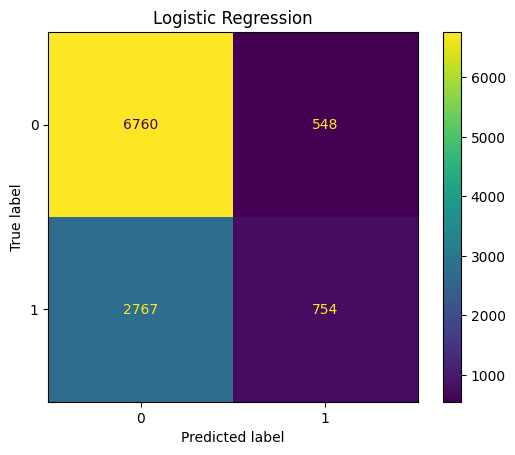

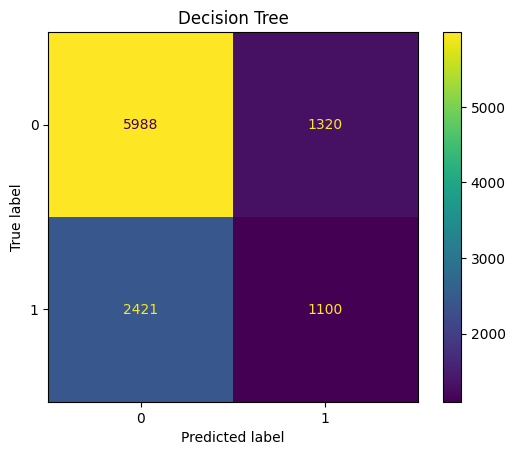

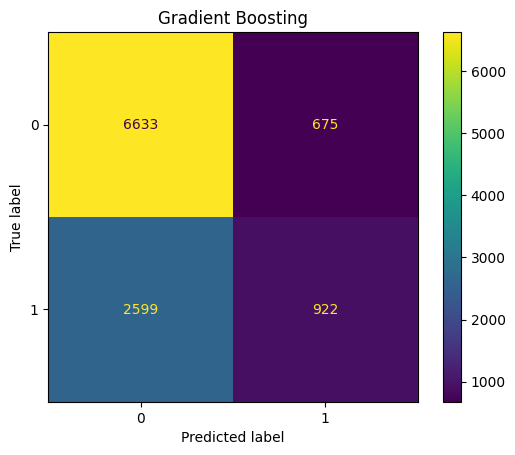

In [42]:
for name, model in pipelines.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(name)
    plt.show()

In [43]:
# Finally we are going to save the dataset cleaned
df_usagers.to_csv("df_usagers_clean.csv", index=False)